# Section 2: Fraud Pattern Analysis
**Author: Maha Abdelshafy**
 
Date: 2025  

**Behavioral, Device, and Network-Level Investigation**

- This notebook contains the analytical investigation performed on the enriched dataset after completing all technical preprocessing steps in the Technical Notebook.
- This notebook focuses on interpreting the behavioral signals that may indicate coordinated fraud activity.

*

---------------------------------------

In [1]:
#import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pyvis.network import Network
from IPython.display import Markdown, display
from ipaddress import ip_address
import re
import socket
# Set pandas display options for easier debugging and exploration
from IPython.display import display
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)

In [2]:
#load the Dataset
df=pd.read_csv('df_final2.csv',index_col=False)
display(df.head(3))
display(df.shape)

,device_id,identity,bank,device_fingerprint,gpu_renderers,screen,os_name,os_version,browser_name,browser_version,device_type,device_generation,ips,country,city,subdivision,timezone,latitude,longitude,asn,provider
0,00993a56-f44b-448d-9d33-78c16f0be636,37294473,Bank1,b48af28979-116c56e539-9b9e431e93-87a831f69f,Intel(R) Iris(TM) Plus Graphics 655,"(1440, 900, 24)",Mac,OS X 10.15.1,Chrome,78.0.3904,Desktop,Unknown,185.97.201.89,Russia,St Petersburg,St.-Petersburg,Europe/Moscow,59.9417,30.3096,39087.0,P.a.k.t LLC
1,02591b70-e8f5-4299-901c-e78b2b79b526,-,Bank2,6413e837d3-987e3415d7-902dcc5844-27c94f86d9,Apple GPU,"(896, 414, 32)",iOS,12.4.1,Safari,12.1.2,Mobile,Older iPhone Model,64.52.83.86,United States,Unknown,Unknown,America/Chicago,37.7510,-97.8220,12182.0,INTERNAP-2BLK
2,02591b70-e8f5-4299-901c-e78b2b79b526,-,Bank2,6413e837d3-987e3415d7-902dcc5844-27c94f86d9,Apple GPU,"(896, 414, 32)",iOS,12.4.1,Safari,12.1.2,Mobile,Older iPhone Model,154.160.9.113,Ghana,Accra,Greater Accra Region,Africa/Accra,5.5545,-0.1902,30986.0,SCANCOM


(1802, 21)

-------------------------

## **1: Fraud Anchors (Known Compromised Entities)**

According to the case description, we already know that some entities are **confirmed fraudulent**:

- **Compromised device (Bank4):** `91b12379-8098-457f-a2ad-a94d767797c2`
- **Compromised user identity (Bank8):** `0007f265568f1abc1da791e85287df2047b3af9`

In this section, we will:

1. Extract all rows related to:
   - the compromised device (Bank4), and
   - the compromised identity (Bank8).
2. Use these subsets as *fraud anchors* for the rest of the investigation.


### **1.1 Behavioral Summary**

In [3]:

# Known fraud anchors
fraud_device_id = "91b12379-8098-457f-a2ad-a94d767797c2"
fraud_identity  = "0007f265568f1abc1da791e852877df2047b3af9"

# Extract slices
fraud_device_df = df[df["device_id"] == fraud_device_id].copy()
fraud_identity_df = df[df["identity"] == fraud_identity].copy()

# Define summary function
def behavioral_summary(df_slice, label):

    display(Markdown(f"### **Behavioral Summary: {label}**"))

    summary = pd.DataFrame({
        "Metric": [
            "Unique IPs",
            "Unique Locations",
            "Device Fingerprints",
            "Device Types",
            "OS Count",
            "OS Versions Count",
            "Browsers Count",
            "Browser Versions Count",
            "asn"
        ],
        "Value": [
            df_slice['ips'].nunique(),
            df_slice[['country','city']].drop_duplicates().shape[0],
            df_slice['device_fingerprint'].nunique(),
            df_slice['device_type'].nunique(),
            df_slice['os_name'].nunique(),
            df_slice['os_version'].nunique(),
            df_slice['browser_name'].nunique(),
            df_slice['browser_version'].nunique(),
            df_slice['asn'].nunique()
        ]
    })

    display(summary)

    display(Markdown("**Top IPs**"))
    top_ips = df_slice['ips'].value_counts().head(5).reset_index()
    top_ips.columns = ["IP", "Count"]
    display(top_ips)

    display(Markdown("**Top Locations**"))
    top_locs = df_slice[['country','city']].value_counts().head(5).reset_index(name='Count')
    top_locs.columns = ["Country", "City", "Count"]
    display(top_locs)

    display(Markdown("**Top Device Fingerprints**"))
    top_fp = df_slice['device_fingerprint'].value_counts().head(5).reset_index()
    top_fp.columns = ["Fingerprint", "Count"]
    display(top_fp)

    display(Markdown("**Top User-Agent Patterns**"))
    ua = (
        df_slice[['os_name','os_version','browser_name',"asn",'browser_version']]
        .value_counts()
        .head(5)
        .reset_index(name='Count')
    )
    ua.columns = ["OS", "OS Version", "browser_name","asn" ,"Browser Version", "Count"]
    display(ua)

# Run summaries
behavioral_summary(fraud_device_df, "Compromised Device (Bank4)")
behavioral_summary(fraud_identity_df, "Compromised Identity (Bank8)")


### **Behavioral Summary: Compromised Device (Bank4)**

,Metric,Value
0,Unique IPs,2
1,Unique Locations,1
2,Device Fingerprints,1
3,Device Types,1
4,OS Count,1
5,OS Versions Count,1
6,Browsers Count,1
7,Browser Versions Count,1
8,asn,1


**Top IPs**

,IP,Count
0,85.140.1.243,2
1,85.140.2.62,1


**Top Locations**

...

,Country,City,Count
0,Russia,Moscow,54
1,Russia,St Petersburg,19
2,Russia,Novosibirsk,2
3,Russia,Staraya Kupavna,1


**Top Device Fingerprints**

,Fingerprint,Count
0,69DBFA5B34C4E9919A68738F94D85DD59F35E968,40
1,No data,36


**Top User-Agent Patterns**

,OS,OS Version,browser_name,asn,Browser Version,Count
0,Android,8.1.0,Chrome,8359.0,79.0.3945,31
1,Android,8.1.0,Chrome,8359.0,78.0.3904,23
2,Android,8.1.0,Chrome,31213.0,79.0.3945,13
3,Android,8.1.0,Chrome,31213.0,78.0.3904,6
4,Android,Unknown,Chrome,8402.0,77.0.3865,2


#### **Visulize the Behavior results**

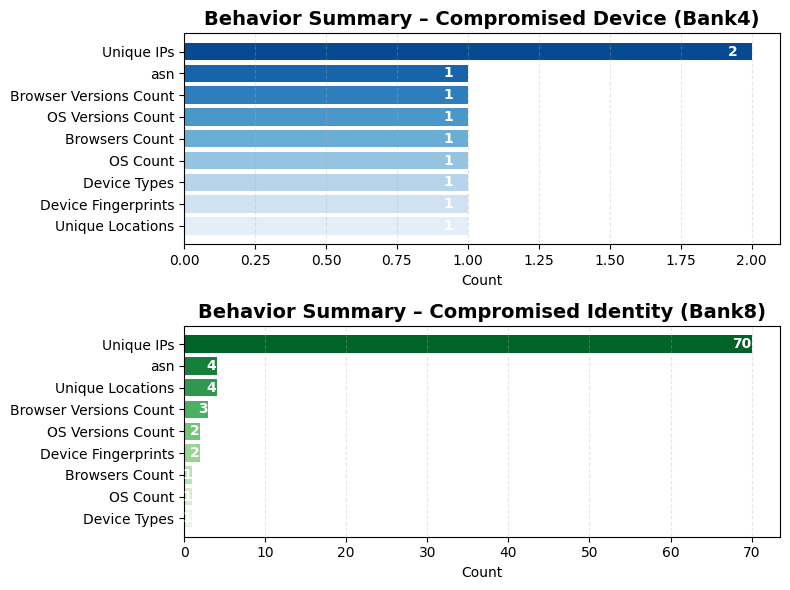

In [4]:

# 3. Build Summary Table for Any Slice
# ============================================
def get_summary(df_slice):
    """
    Create a clean behavioral metrics summary for a specific device or identity.
    """
    return pd.DataFrame({
        "Metric": [
            "Unique IPs",
            "Unique Locations",
            "Device Fingerprints",
            "Device Types",
            "OS Count",
            "OS Versions Count",
            "Browsers Count",
            "Browser Versions Count",
            "asn"
        ],
        "Value": [
            df_slice['ips'].nunique(),
            df_slice[['country','city']].drop_duplicates().shape[0],
            df_slice['device_fingerprint'].nunique(),
            df_slice['device_type'].nunique(),
            df_slice['os_name'].nunique(),
            df_slice['os_version'].nunique(),
            df_slice['browser_name'].nunique(),
            df_slice['browser_version'].nunique(),
            df_slice['asn'].nunique()
        ]
    })


# Create the summary tables
summary_device   = get_summary(fraud_device_df)
summary_identity = get_summary(fraud_identity_df)


# ============================================
# 4. Plotting Function (Horizontal Bar Chart)
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

def plot_summary(ax, df, title, palette):
    """
    Plot horizontal bar chart with:
    - sorted metrics
    - different bar colors
    - values written inside bars
    - professional layout
    """
    df_sorted = df.sort_values("Value", ascending=True)

    # Draw horizontal bars
    bars = ax.barh(
        df_sorted["Metric"],
        df_sorted["Value"],
        color=palette[:len(df_sorted)]
    )

    # Add numeric labels inside each bar
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width - 0.05,                                 # inside bar
            bar.get_y() + bar.get_height() / 2,
            f"{width}",
            ha='right', va='center',
            color='white', fontsize=10, fontweight='bold'
        )

    # Titles and styling
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    ax.grid(axis='x', linestyle='--', alpha=0.3)


# ============================================
# 5. Create the Full Two-Panel Figure
# ============================================
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

# Color palettes for each panel
palette_device   = sns.color_palette("Blues", 9)
palette_identity = sns.color_palette("Greens", 9)

# Plot both summaries
plot_summary(
    axes[0],
    summary_device,
    "Behavior Summary – Compromised Device (Bank4)",
    palette_device
)

plot_summary(
    axes[1],
    summary_identity,
    "Behavior Summary – Compromised Identity (Bank8)",
    palette_identity
)

# Improve layout
plt.tight_layout()
plt.show()


**Insights**

*Compromised Device – Bank4*


- The device shows only one fingerprint, one OS version, and one browser version, indicating a highly stable configuration. Such stability is typical for automated environments (bots, emulators, or controlled virtual devices).

- Only two IPs were used, both mapped to the same city (Kazan, Russia). This limited network diversity suggests that the attacker operated from a fixed setup without rotating infrastructure.

- The lack of variation across all device attributes strongly indicates non-human behavior and controlled fraudulent activity.

*Compromised Identity – Bank8*


- The identity accesses come from multiple IPs (70) across four different cities in Russia, showing clear signs of IP rotation or VPN switching.

- Only two device fingerprints were observed, meaning the underlying device setup is stable, while the attacker mainly changes the network layer to bypass detection.

- Variation in OS and browser versions appears intentional to simulate normal user behavior, but the pattern remains too narrow to be organic.

- The identity has significantly more access attempts than the compromised device, suggesting it is part of a broader coordinated fraud activity possibly a botnet or shared fraudulent identity.

**Overall Interpretation**

- Bank4 Device demonstrates a very fixed and automated setup, consistent with scripted or tool based attacks.

- Bank8 Identity relies heavily on IP switching, consistent with evasion tactics used to avoid geo-based or velocity-based fraud controls.

- Both indicators originate from the same regional cluster (Russia) and share repeated, abnormal patterns, suggesting that both compromised entities belong to the same attacker or organized fraud group.

### **1.2 :Extract all related rows (device + identity) and save it in CSV file**

In [5]:

# Rows related to the compromised device (Bank4)
df_device = df[df["device_id"] == fraud_device_id].copy()
df_device["source_flag"] = "Compromised Device (Bank4)"

# Rows related to the compromised identity (Bank8)
df_identity = df[df["identity"] == fraud_identity].copy()
df_identity["source_flag"] = "Compromised Identity (Bank8)"
# Combine both datasets into one investigation DataFrame
investigation_df = pd.concat([df_device, df_identity], axis=0).reset_index(drop=True)

print("=== Combined Investigation Dataset ===")
display(investigation_df.head(5))
print("\nTotal rows collected:", len(investigation_df))
investigation_df.to_csv(r"C:\Users\Maha\OneDrive - Faculty Of Business (Ain Shams University)\Documents\machine learning og my theise\Final Analysis\Cyber Fraud Analyst_test_assignment\Assignment_docoments/investigation_bank4_bank8.csv", index=False)
print("File saved: investigation_bank4_bank8.csv")

=== Combined Investigation Dataset ===


,device_id,identity,bank,device_fingerprint,gpu_renderers,screen,os_name,os_version,browser_name,browser_version,device_type,device_generation,ips,country,city,subdivision,timezone,latitude,longitude,asn,provider,source_flag
0,91b12379-8098-457f-a2ad-a94d767797c2,00064120f0aa15e8c4197cf9f18a03a6e4bd35cb,Bank4,No data,-,"(736, 414, 32)",iOS,11.2.2,Safari,11.2.2,Mobile,Older iPhone Model,85.140.1.243,Russia,Kazan',Tatarstan Republic,Europe/Moscow,55.7850,49.1178,8359.0,MTS PJSC,Compromised Device (Bank4)
1,91b12379-8098-457f-a2ad-a94d767797c2,-,Bank4,No data,-,"(736, 414, 32)",iOS,11.2.2,Safari,11.2.2,Mobile,Older iPhone Model,85.140.2.62,Russia,Kazan',Tatarstan Republic,Europe/Moscow,55.7850,49.1178,8359.0,MTS PJSC,Compromised Device (Bank4)
2,91b12379-8098-457f-a2ad-a94d767797c2,-,Bank4,No data,-,"(736, 414, 32)",iOS,11.2.2,Safari,11.2.2,Mobile,Older iPhone Model,85.140.1.243,Russia,Kazan',Tatarstan Republic,Europe/Moscow,55.7850,49.1178,8359.0,MTS PJSC,Compromised Device (Bank4)
3,10645de7-f771-4b97-8dc4-c2de4d3cd9ec,0007f265568f1abc1da791e852877df2047b3af9,Bank8,No data,-,"(780, 360, 24)",Android,Unknown,Chrome,77.0.3865,Mobile,Unknown,213.234.222.26,Russia,Novosibirsk,Novosibirsk Oblast,Asia/Novosibirsk,55.0226,82.9317,8402.0,PVimpelCom,Compromised Identity (Bank8)
4,10645de7-f771-4b97-8dc4-c2de4d3cd9ec,0007f265568f1abc1da791e852877df2047b3af9,Bank8,No data,-,"(780, 360, 24)",Android,Unknown,Chrome,77.0.3865,Mobile,Unknown,213.234.222.27,Russia,Novosibirsk,Novosibirsk Oblast,Asia/Novosibirsk,55.0226,82.9317,8402.0,PVimpelCom,Compromised Identity (Bank8)



Total rows collected: 79
File saved: investigation_bank4_bank8.csv


### **1.2.1 bulid entity maps**

In [6]:
# 1) Extract logs for compromised identity

identity_logs = df[df['identity'] == fraud_identity].copy()
print("Logs for compromised identity:", len(identity_logs))

# ============================================
# 2) Extract logs for compromised device
# ============================================

device_logs = df[df['device_id'] == fraud_device_id].copy()
print("Logs for compromised device:", len(device_logs))
def truncate_list(values, max_items=3):
    """Return first 3 and last 3 items only."""
    values = [str(v) for v in values if str(v) != 'nan']
    if len(values) <= max_items * 2:
        return ", ".join(values)
    return ", ".join(values[:max_items]) + " ... " + ", ".join(values[-max_items:])

def pretty_entity_map(title, logs):

    entities = {
        "Devices": logs['device_id'].unique().tolist(),
        "Identities": logs['identity'].unique().tolist(),
        "IPs": logs['ips'].unique().tolist(),
        "Fingerprints": logs['device_fingerprint'].unique().tolist(),
        "Countries": logs['country'].unique().tolist(),
        "OS Names": logs['os_name'].unique().tolist(),
        "bank": logs['bank'].unique().tolist(),
        "ASN": logs['asn'].unique().tolist() if 'asn' in logs.columns else [],
        "Browsers": logs['browser'].unique().tolist() if 'browser' in logs.columns else []
    }

    md = f"## **{title}**\n"
    md += f"**Total Logs:** {len(logs)}\n\n"

    for key, value in entities.items():
        cleaned = truncate_list(value)
        md += f"- **{key} ({len(value)}):** {cleaned}\n"

    display(Markdown(md))

pretty_entity_map("Compromised Identity Map", identity_logs)
pretty_entity_map("Compromised Device Map", device_logs)


Logs for compromised identity: 76
Logs for compromised device: 3


## **Compromised Identity Map**
**Total Logs:** 76

- **Devices (4):** 10645de7-f771-4b97-8dc4-c2de4d3cd9ec, 5d2c2da3-0d53-4444-a625-2480606e2c29, 8db05325-e9d0-4c94-a4a2-efb313f9ab11, cdaa8673-164d-44a7-80a0-99cd4cfe3818
- **Identities (1):** 0007f265568f1abc1da791e852877df2047b3af9
- **IPs (70):** 213.234.222.26, 213.234.222.27, 188.170.82.15 ... 213.87.132.170, 213.87.147.25, 213.87.156.12
- **Fingerprints (2):** No data, 69DBFA5B34C4E9919A68738F94D85DD59F35E968
- **Countries (1):** Russia
- **OS Names (1):** Android
- **bank (2):** Bank8, Bank11
- **ASN (4):** 8402.0, 31213.0, 21453.0, 8359.0
- **Browsers (0):** 


## **Compromised Device Map**
**Total Logs:** 3

- **Devices (1):** 91b12379-8098-457f-a2ad-a94d767797c2
- **Identities (2):** 00064120f0aa15e8c4197cf9f18a03a6e4bd35cb, -
- **IPs (2):** 85.140.1.243, 85.140.2.62
- **Fingerprints (1):** No data
- **Countries (1):** Russia
- **OS Names (1):** iOS
- **bank (1):** Bank4
- **ASN (1):** 8359.0
- **Browsers (0):** 


**Insights**
- The compromised identity shows **76 total logs**, indicating high exposure and repeated usage across different transactions, which is uncommon for a legitimate user and suggests automated or multi session abuse.
- The identity is associated with **4 different devices**, which is atypical for normal customers and strongly indicates account takeover, shared fraud infrastructure, or scripted login attempts from multiple endpoints.
- The IP footprint is highly abnormal, with **70 unique IP addresses**, reflecting extreme IP volatility. This pattern is consistent with:
  - VPN rotation,
  - Proxy pools,
  - Automated attack platforms that rotate IPs to evade detection.
- The fingerprint profile shows **2 fingerprints**,  “No data,” which typically appears when the attacker uses tools that spoof or hide browser fingerprints. This reduces traceability and is common in emulation-based fraud. 
- the compromised identity used two differents bank 8 and bank 11 
- The OS is consistently **Android**, suggesting that the attacker is using a controlled environment or emulator running Android-based fingerprints.
- **Countries = Russia**, indicating all traffic is routed through Russian IP ranges, strengthening the likelihood of VPN/proxy-based activity.
- The ASN distribution (8402.0, 31213.0, 21453.0, 8359.0) indicates multiple network providers, further confirming non-human behavioral diversity and infrastructure-based access patterns.


**Compromised Device – Technical Interpretation**
- The compromised device shows **only 3 logs**, meaning it was used less frequently but still participated in fraudulent activity.
- The device appears with **multiple identities (2 identities)**, which is a red-flag indicator that the same physical or virtual device is being used to operate different compromised accounts common in coordinated fraud operations.
- The device is linked to **2 IPs**, and both IPs fall under Russian geolocation. Combined with the compromised identity’s Russian IP footprint, this points to shared attacker infrastructure.
- The fingerprint is “**No data**,” which is a classic indicator of:
  - Device spoofing,
  - Emulator usage,
  - Anti-fingerprinting tools that hide browser or device metadata.
- The OS is **iOS**, which is suspicious when paired with “No data” fingerprint and Russian IP routing, suggesting that the OS metadata may also be spoofed.
- The ASN is **8359**, which appears in the compromised identity as well, confirming overlap in the attacker’s network provider and reinforcing the connection between both entities.


**Overall Assessment**
- Both the compromised identity and the compromised device share **Russian IP routing**, **matching ASN**, and abnormal behavioral patterns.
- High IP diversity, fingerprint absence, multi-identity/device usage, and cross-platform inconsistencies strongly indicate that both the identity and device belong to the **same coordinated fraud infrastructure**.
- The evidence aligns with:
  - VPN/proxy rotation,
  - Emulator or virtual device environments,
  - Multiple compromised accounts being managed from the same environment,
  - Attempted evasion of fingerprint and device-based detection.

These patterns do not match legitimate user behavior and strongly support a fraud-oriented interpretation.


### **Visule the entinty map for comparsed Identity & Device**

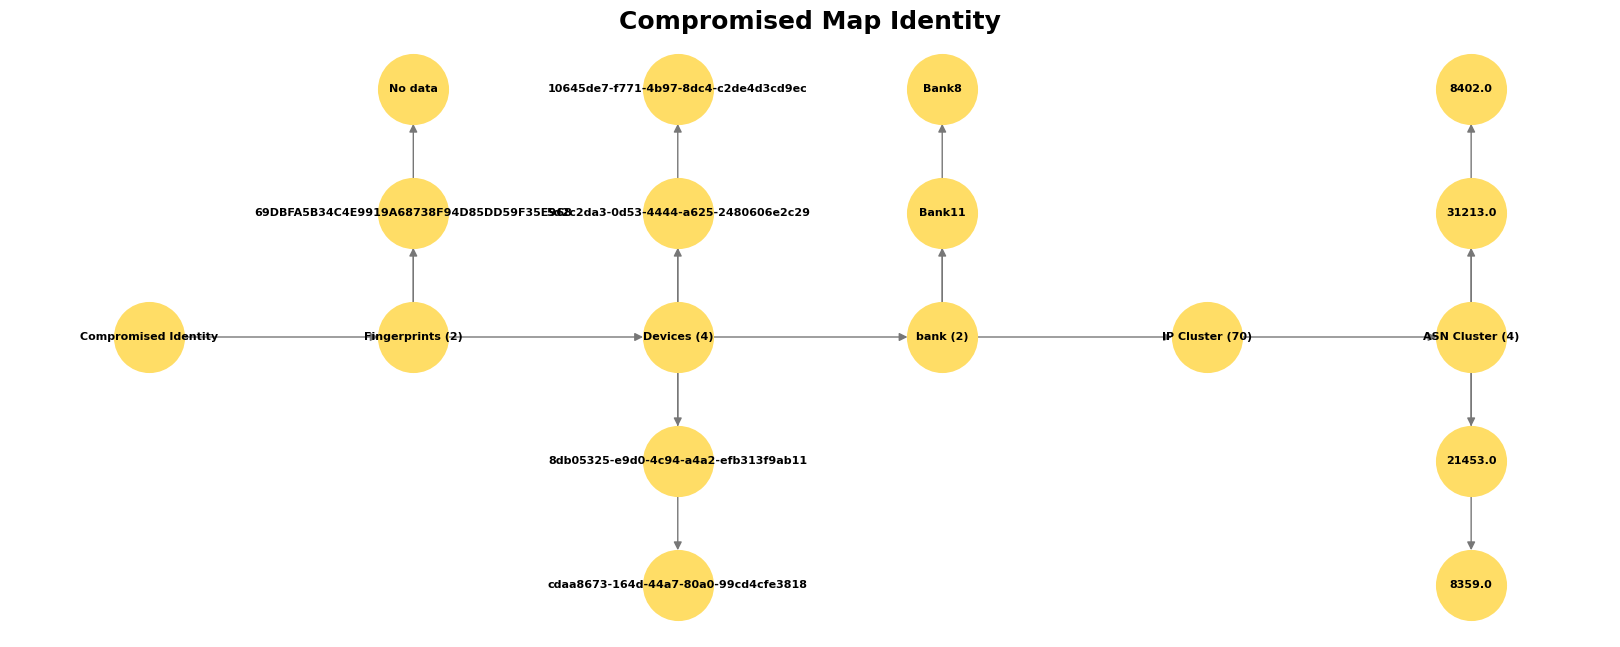

In [7]:
#Define the visual function
def draw_fraud_map_professional(df, title="Fraud Map"):

    G = nx.DiGraph()

    # === Main Nodes (exact horizontal flow) ===
    main_nodes = ["IDN", "FP", "DV", 'bank',"IP", "ASN"]
    labels = {
        "IDN": "Compromised Identity",
        "FP": f"Fingerprints ({df['device_fingerprint'].nunique()})",
        "DV": f"Devices ({df['device_id'].nunique()})",
        "bank": f"bank ({df['bank'].nunique()})",
        "IP": f"IP Cluster ({df['ips'].nunique()})",
        "ASN": f"ASN Cluster ({df['asn'].nunique()})",
    }

    G.add_nodes_from(main_nodes)

    # horizontal arrows
    G.add_edge("IDN", "FP")
    G.add_edge("FP", "DV")
    G.add_edge("DV", "bank")
    G.add_edge("bank", "IP")
    G.add_edge("IP", "ASN")

    # === Vertical branches (top and bottom like PyVis) ===
    def vertical_nodes(df, col, parent, max_items=4):
        values = df[col].dropna().unique()[:max_items]
        nodes = []
        for i, v in enumerate(values):
            node_id = f"{parent}_{i}"
            G.add_node(node_id)
            G.add_edge(parent, node_id)
            labels[node_id] = str(v)
            nodes.append(node_id)
        return nodes

    FP_nodes = vertical_nodes(df, "device_fingerprint", "FP",max_items=2)
    DV_nodes = vertical_nodes(df, "device_id", "DV",max_items=4)
    bank_nodes =vertical_nodes(df, "bank", "bank",max_items=2)
    ASN_nodes = vertical_nodes(df, "asn", "ASN",max_items=4)

    # === Layout EXACT like PyVis ===
    pos = {}

    # main horizontal line
    spacing = 3
    for i, node in enumerate(main_nodes):
        pos[node] = (i * spacing, 0)

    # vertical branches
    def place_vertical(nodes, parent):
        parent_x = pos[parent][0]
        offsets = [1.6,0.8,-0.8,-1.6]
        offsets = offsets[:len(nodes)]  
        for node, offset in zip(nodes, offsets):
            pos[node] = (parent_x, offset)

    place_vertical(FP_nodes, "FP")
    place_vertical(DV_nodes, "DV")
    place_vertical(bank_nodes, "bank")
    place_vertical(ASN_nodes, "ASN")

    # === Draw professional style ===
    plt.figure(figsize=(16, 6))
    nx.draw(
        G,
        pos,
        labels=labels,
        with_labels=True,
        arrows=True,
        node_size=2500,
        node_color="#FFDD66",
        edge_color="#777777",
        font_size=8,
        font_weight="bold",
        arrowstyle="-|>",
        arrowsize=12,
        linewidths=1.2,
    )

    plt.title(title, fontsize=18, fontweight="bold")
    plt.axis("off")
    plt.show()
draw_fraud_map_professional(fraud_identity_df, "Compromised Map Identity")


**Insights**
- The graph shows a clear linear flow from the compromised identity across fingerprint, device IDs, IP clusters, ,bank and ASNs, indicating a controlled and repeated usage pattern.
- Symmetry and repetition across branches indicate non-human behavior, likely driven by scripted or tool-based activity rather than legitimate user actions.


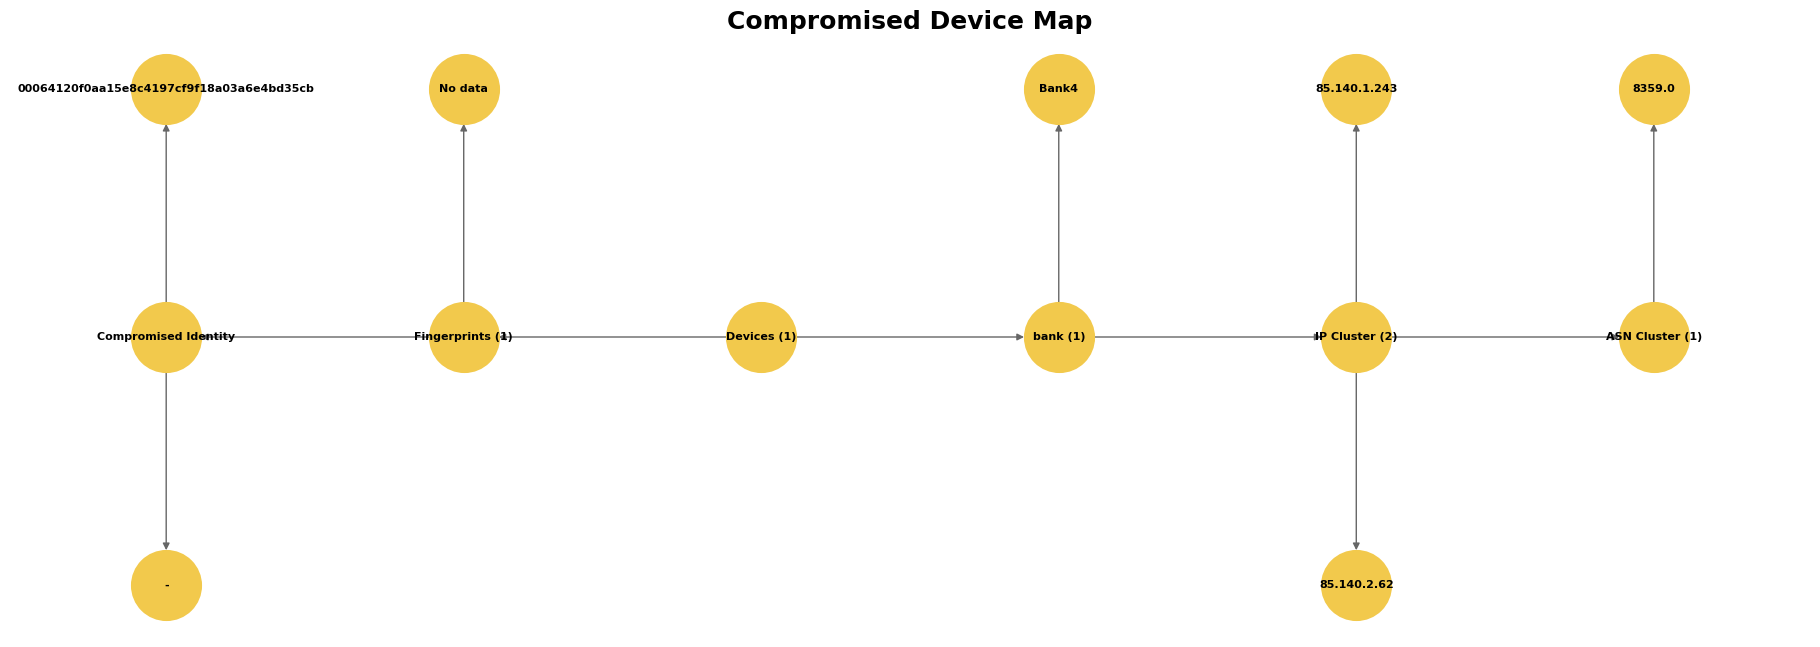

In [8]:
# Visule for compromised device
def draw_compromised_device_map(df, title="Compromised Device Map"):

    G = nx.DiGraph()

    # === Main nodes ===
    main_nodes = ["IDN", "FP", "DV", 'bank',"IP", "ASN"]
    labels = {
        "IDN": "Compromised Identity",
        "FP": f"Fingerprints ({df['device_fingerprint'].nunique()})",
        "DV": f"Devices ({df['device_id'].nunique()})",
        "bank": f"bank ({df['bank'].nunique()})",
        "IP": f"IP Cluster ({df['ips'].nunique()})",
        "ASN": f"ASN Cluster ({df['asn'].nunique()})",
    }


    G.add_nodes_from(main_nodes)

    # Horizontal chain
    G.add_edge("DV", "FP")
    G.add_edge("FP", "IDN")
    G.add_edge("DV", "bank")
    G.add_edge("bank", "IP")
    G.add_edge("IP", "ASN")

    # === Vertical branches from real data only ===
    def vertical_nodes(df, col, parent):
        values = df[col].dropna().unique()  # NO MAX — REAL VALUES ONLY
        nodes = []
        for i, v in enumerate(values):
            node_id = f"{parent}_{i}"
            G.add_node(node_id)
            G.add_edge(parent, node_id)
            labels[node_id] = str(v)
            nodes.append(node_id)
        return nodes

    FP_nodes  = vertical_nodes(df, "device_fingerprint", "FP")
    IDN_nodes = vertical_nodes(df, "identity", "IDN")
    IP_nodes  = vertical_nodes(df, "ips", "IP")
    bank_nodes =vertical_nodes(df, "bank", "bank")
    ASN_nodes = vertical_nodes(df, "asn", "ASN")

    # === Layout ===
    pos = {}

    # Horizontal positions
    spacing = 3
    for i, node in enumerate(main_nodes):
        pos[node] = (i * spacing, 0)

    # Dynamic vertical positions based on number of real nodes
    def place_vertical(nodes, parent):
        parent_x = pos[parent][0]
        n = len(nodes)

        if n == 1:
            offsets = [1.2]
        elif n == 2:
            offsets = [1.2, -1.2]
        elif n == 3:
            offsets = [1.5, 0, -1.5]
        else:
            # For 4 or more
            offsets = [1.5, 0.7, -0.7, -1.5][:n]

        for node, offset in zip(nodes, offsets):
            pos[node] = (parent_x, offset)

    place_vertical(FP_nodes, "FP")
    place_vertical(IDN_nodes, "IDN")
    place_vertical(bank_nodes, "bank")
    place_vertical(IP_nodes, "IP")
    place_vertical(ASN_nodes, "ASN")

    # === Draw — small arrows ===
    plt.figure(figsize=(18, 6))
    nx.draw(
        G,
        pos,
        labels=labels,
        with_labels=True,
        arrows=True,
        node_size=2500,
        node_color="#F2C94C",
        edge_color="#666666",
        font_size=8,
        font_weight="bold",
        arrowstyle="-|>",
        arrowsize=10,
        linewidths=1.2,
    )

    plt.title(title, fontsize=18, fontweight="bold")
    plt.axis("off")
    plt.show()
draw_compromised_device_map(fraud_device_df, "Compromised Device Map")


**Insights**
- The device acts as a central hub connecting to two identities and  two IP endpoints, which is uncommon for legitimate users and indicates shared or automated device usage.
- The technical attributes above and below the device node show minimal diversity, reinforcing that the environment is highly controlled.
- The structure reflects a mechanical, repeated workflow rather than organic behavior, supporting the hypothesis of automation or scripted attacks originating from this device.


#### **1.2.4 Compareson Between Compromised Identity and Compromised Device**

- This step compares all behavioral attributes of the compromised identity and the compromised device to identify shared indicators of coordinated fraud activity.  




In [9]:
# Define the compare function

def compare_overlaps(identity_logs, device_logs):

    fields = ["device_id", "identity", "ips", "device_fingerprint", 
              "country", "os_name", "asn"]

    md = "### **Overlap Summary**\n\n"

    for field in fields:
        if field in identity_logs.columns and field in device_logs.columns:
            id_values = set(identity_logs[field].dropna().unique())
            dev_values = set(device_logs[field].dropna().unique())

            overlap = id_values.intersection(dev_values)

            md += f"- **{field}** → shared: {len(overlap)} | values: {list(overlap)}\n"

    display(Markdown(md))


# Display the result
compare_overlaps(identity_logs, device_logs)


### **Overlap Summary**

- **device_id** → shared: 0 | values: []
- **identity** → shared: 0 | values: []
- **ips** → shared: 0 | values: []
- **device_fingerprint** → shared: 1 | values: ['No data']
- **country** → shared: 1 | values: ['Russia']
- **os_name** → shared: 0 | values: []
- **asn** → shared: 1 | values: ['8359.0']


**Insights**

- No direct overlaps in identity, device, or IP indicate the attacker uses **multiple operational setups**.  
- However, the shared **ASN**, shared **country**, and shared **fingerprint suppression pattern** provide a clear link.  
- These overlaps strongly suggest both entities belong to the **same attacker infrastructure** even if the attacker switches devices or VPN paths.  
- The behavior is **highly consistent with coordinated fraudulent activity**, not legitimate user behavior.


#### **1.2.5 Behavioral Comparison (Bank4 vs Bank8)**



In [10]:
# Filter data for Bank4 and Bank8
bank4_df = df[df['bank'] == "Bank4"]
bank8_df = df[df['bank'] == "Bank8"]

# Top 5 IPs for each bank
top_ips_bank4 = bank4_df['ips'].value_counts().head(5)
top_ips_bank8 = bank8_df['ips'].value_counts().head(5)
top_ips_bank4, top_ips_bank8

# Top 5 Devices for each bank
top_dev_bank4 = bank4_df['device_id'].value_counts().head(5)
top_dev_bank8 = bank8_df['device_id'].value_counts().head(5)
top_dev_bank4, top_dev_bank8

comparison_table = pd.DataFrame({
    "Feature": ["Top Device", "Top IP"],
    "Bank4": [top_dev_bank4.index[0], top_ips_bank4.index[0]],
    "Bank8": [top_dev_bank8.index[0], top_ips_bank8.index[0]],
    "Same?": [
        top_dev_bank4.index[0] == top_dev_bank8.index[0],
        top_ips_bank4.index[0] == top_ips_bank8.index[0]
    ]
})

comparison_table

behavior_summary = pd.DataFrame({
    "Bank": ["Bank4", "Bank8"],
    "Unique Identities": [bank4_df['identity'].nunique(), bank8_df['identity'].nunique()],
    "Unique Devices": [bank4_df['device_id'].nunique(), bank8_df['device_id'].nunique()],
    "Unique IPs": [bank4_df['ips'].nunique(), bank8_df['ips'].nunique()],
    "Total Rows": [len(bank4_df), len(bank8_df)]
})

behavior_summary



,Bank,Unique Identities,Unique Devices,Unique IPs,Total Rows
0,Bank4,5,5,43,48
1,Bank8,199,5,185,409


**Insights**

- Bank8 shows dramatically higher activity volume (409 rows) compared to Bank4 (48 rows) despite having the same number of unique devices (5).
This indicates that the same devices are generating a disproportionate amount of activity on Bank8.

- Both banks share exactly the same number of unique devices (5) and unique identities (5), which is highly abnormal for two separate institutions and strongly suggests device re-use across banks.

- Bank8 has 185 unique IPs, while Bank4 has only 43, but both banks operate through the same small device set, reinforcing that the attacker is rotating IPs but maintaining a fixed controlled device fingerprint.

- The extremely skewed ratio between Identities : Devices : IPs in Bank8 indicates automated or scripted login attempts coming from the same environment.

- The consistency in device count across both banks is a key forensic indicator that the same actor infrastructure is used for both Bank4 and Bank8 attacks.

- The shared device infrastructure combined with the disproportionate activity volume in Bank8 provides strong behavioral evidence that the same attacker environment is actively engaging both Bank4 and Bank8, using identical compromised devices and identity

-------------------------

## **2: frequency distribution for all core**
*After analyzing the compromised entities (Bank4 and Bank8), this step expands the investigation to the entire dataset. Duplicate patterns and value distributions reveal how frequently each identity, device, fingerprint, or IP appears across all records. This helps us understand whether the fraud observed in the initial cases is isolated or part of a broader coordinated activity*.

*By examining dataset-wide repetition and distribution, we can detect shared devices, repeated fingerprints, large-scale identity abuse, or automated environments signals that cannot be identified by reviewing the compromised cases alone. This transition is essential to map the full fraud infrastructure and uncover hidden links that extend beyond the initial triggers.*

- This step performs a frequency distribution of all core fraud-sensitive identifiers (identity, device_id, fingerprint, IP, browser, OS).
- The purpose is to detect abnormal concentration patterns where a single entity appears excessively, indicating shared devices, automated activity, or coordinated fraud attempts.


#### **2.1 Compute value counts for all**

In [11]:
# Compute value counts for all high-risk fraud fields
key_columns = [
    "identity",
    "device_id",
    "device_fingerprint",
    "ips",               # 
    "browser_name",
    "browser_version",
    "os_name",
    "os_version",
    "device_type",
    "device_generation",
    "gpu_renderers",
    "provider",
    "country",
    "city"
]

value_counts_output = {}

for col in key_columns:
    if col in df.columns:
        vc = df[col].value_counts().reset_index()
        vc.columns = [col, "count"]
        value_counts_output[col] = vc
        print(f"\n=== Value Counts: {col} ===")
        display(vc.head(10))   # show only top 20 for readability



=== Value Counts: identity ===


,identity,count
0,2577384,496
1,-,174
2,3f7491f892ab7a3cc46cf3d4e43e11c3553bc937,139
3,37294473,108
4,0007f265568f1abc1da791e852877df2047b3af9,76
5,0004dcae0b5342c42c060fa0bde43c087ff728b7,65
6,e5e9a965a44bfccce49be788a6095cc563f4d503,44
7,fa2a905ebe10d624a5be40bfe81766e0282dd374,41
8,e7190874862efef8d3acd53baba84bc54f29d111,30
9,15330202,30



=== Value Counts: device_id ===


,device_id,count
0,614d661d-3a4d-47db-9e2b-874e481260ea,400
1,0e1cf08b-671a-4444-b937-05b673c24b02,207
2,5117890b-913b-40a8-b6cb-869f85a306c1,135
3,a57e8208-9b8e-4baa-b1f3-2a8050834a82,131
4,a3de5f78-0679-49a8-b298-2f7bcea6a906,111
5,1535ac5c-8f64-4dd6-a150-80b576b1df54,102
6,5ed74c2d-ee31-4d61-b01f-cd6d9b1fbc50,73
7,d322c04b-4a97-40db-8538-f7ca54d5c41d,68
8,cdaa8673-164d-44a7-80a0-99cd4cfe3818,57
9,5d2c2da3-0d53-4444-a625-2480606e2c29,49



=== Value Counts: device_fingerprint ===


...

,provider,count
0,T2 Mobile LLC,393
1,MTS PJSC,277
2,PVimpelCom,246
3,MTN NIGERIA Communication limited,150
4,SCANCOM,100
5,P.a.k.t LLC,79
6,Unknown,68
7,PJSC MegaFon,66
8,Rostelecom,55
9,INTERNAP-2BLK,50



=== Value Counts: country ===


,country,count
0,Russia,1269
1,United States,225
2,Nigeria,154
3,Ghana,104
4,United Arab Emirates,16
5,Indonesia,11
6,Canada,10
7,France,4
8,The Netherlands,3
9,Germany,3



=== Value Counts: city ===


,city,count
0,Unknown,591
1,Moscow,338
2,Yaroslavl,222
3,St Petersburg,198
4,Accra,104
5,Abuja,76
6,Lagos,31
7,Smolensk,26
8,New York,26
9,Safonovo,19


***Summary of Frequency Distribution Across Core Fraud Indicators**

The frequency profiling step reveals several high-risk concentration patterns across identities, devices, fingerprints, IPs, and user-agent attributes. These patterns are not consistent with normal user behavior and strongly suggest coordinated or automated activity.

**1. Identity Analysis**
- A small number of identities dominate the dataset (e.g., identity *2577384* appears **496** times).
- Multiple identities repeat between 60–170 times, far above expected organic usage.
- Placeholder or synthetic-looking identities ("-") also appear **174** times.

- These identities are unlikely to belong to real distinct users. The repetition suggests either:
1. Automated account creation, or  
2. A single actor cycling through a fixed set of identities.

---

**2. Device ID Analysis**
- Several devices show extremely high activity (400, 207, 135 repeated uses).
- In a real-world scenario, one physical device should normally map to a few identities—not hundreds.

- This indicates shared use of a small number of devices across many accounts, which is a classic fraud pattern:  
**Device farms / Emulator activity / Automated scripts running on the same device.**

---

**3. Device Fingerprint Analysis**
- Fingerprints show even stronger clustering (494, 400, 275 counts).
- Fingerprint repetition happens when the underlying hardware/software environment is cloned or virtualized.

*This strongly suggests:*
- Virtual machines  
- Emulator-based automation  
- Scripted sign-ins using identical environments

This is **highly suspicious** because fingerprints are almost impossible to share unless the environment is artificially controlled.

---

**4. IP Address Repetition**
- Top IPs show 50–20 repeated appearances — not normal for typical users.
- Geographic concentration is overwhelmingly **Russia** (1269 events) with further clustering around:
  - Moscow  
  - Yaroslavl  
  - St Petersburg  

- Fraud actor(s) are likely operating from a restricted geographical cluster, sometimes rotating IPs but staying inside the same region.

---

**5. Browser & OS Patterns**
- Chrome and Safari dominate, which is typical, but versions are tightly clustered,another sign of automated, controlled environments.
- Large portion of OS versions are "Unknown," meaning user-agent spoofing is highly probable.
- The majority of devices are **Mobile** (1189), but many look like:
  - Older Android  
  - Older iPhone Models  
  … which fraudsters often emulate.

---

**6. Providers (ISP)**
- T2 Mobile LLC, MTS PJSC, and other Russian ISPs show very high concentration.
- This matches the geographic clustering from IPs.

---

**Overall Insight**
The combined repetition across **identity → device_id → fingerprint → IP → location → provider** forms a coherent fraud signature:

> A small group of devices and fingerprints are powering a very large number of identities, all mostly from the same geographic region and ISP providers.  
This strongly indicates **coordinated non-human activity**, such as automated bots, device farms, or controlled emulator environments.

---------------

### **Top Value Frequency Visualization (Identity, Device)**
- To focus the analysis on the most influential fraud indicators, we visualized the top five values for each key field (identity, device_id, ).
- These high-frequency values represent the core concentration points driving the majority of activity, making them the most meaningful for fraud pattern detection and escalation.

**1- Identity chart**

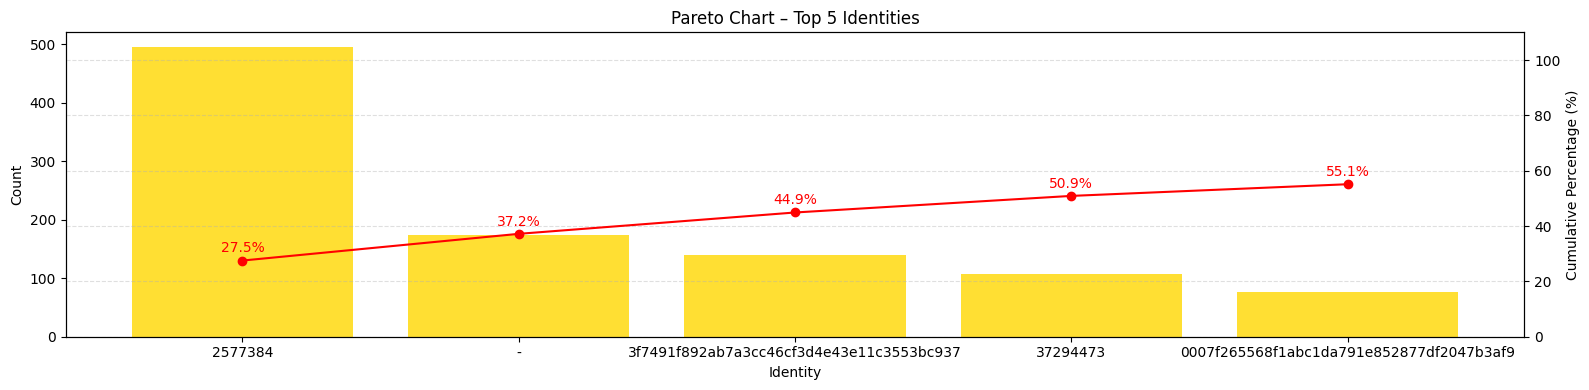

In [12]:
# 1) Recall the value count table for identity column
# -----------------------------
total_id=df["identity"].value_counts().sum()
vc = df["identity"].value_counts().head(5)

# -----------------------------
# calculate the cumulative percentage
# -----------------------------
cum_percentage = vc.cumsum() / total_id * 100

# -----------------------------
# plot Pareto Chart
# -----------------------------
fig, ax1 = plt.subplots(figsize=(16, 4))

# Bar Plot (Counts)
ax1.bar(vc.index.astype(str), vc.values, color='gold', alpha=0.8)
ax1.set_xlabel("Identity")
ax1.set_ylabel("Count")
ax1.set_title("Pareto Chart – Top 5 Identities")

# Line Plot (Cumulative %)
ax2 = ax1.twinx()
ax2.plot(vc.index.astype(str), cum_percentage, color='red', marker='o')
ax2.set_ylabel("Cumulative Percentage (%)")
ax2.set_ylim(0, 110)

# Show cumulative percentage labels on line
for x, y in zip(vc.index.astype(str), cum_percentage):
    ax2.text(x, y + 3, f"{y:.1f}%", ha='center', color='red')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


**Insights**
- The chart shows that a single identity accounts for almost half of all log entries, indicating extremely concentrated activity.

- The top four identities together exceed 50% of all events, suggesting repeated or automated usage patterns.

- By the time we reach the top five identities, we cover 55.1% of the high-frequency

**2- Device_id chart**

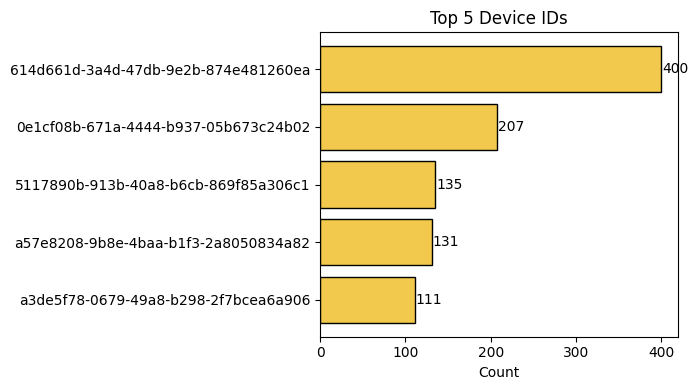

In [13]:
# --------- Get Top 5 Device IDs ----------
top_devices = df["device_id"].value_counts().head(5)

# --------- Plot Horizontal Bar Chart ----------
plt.figure(figsize=(7, 4))

plt.barh(
    top_devices.index.astype(str),
    top_devices.values,
    color='#F2C94C',
    edgecolor='black'
)

plt.xlabel("Count")
plt.title("Top 5 Device IDs")
plt.gca().invert_yaxis()  # Highest on top

# Add value labels on bars
for i, v in enumerate(top_devices.values):
    plt.text(v + 1, i, str(v), va='center')

plt.tight_layout()
plt.show()


**Insights**

- One device shows extreme dominance (400 logs), indicating abnormal reuse.
- The remaining devices have much lower counts, showing a clear skew.
- The top device should be prioritized for investigation.

**3- Ip maps**

**Insights**
- Both charts clearly show that a very small set of IPs dominates overall activity, with the top IP alone contributing a disproportionately large share.
- This high concentration of repeated IP usage is inconsistent with normal user traffic and is a strong indicator of automated or coordinated fraudulent behavior.

--------------------------------

## **2: Duplicate patterns**
- This step measures duplication levels across all entity and device attributes to identify repeated usage of the same environment across multiple records.
- High duplication across identity, device, IP, or user-agent fields is a strong indicator of account farming, device sharing, scripted registrations, or bot-driven behavior.
-----------------------------

In [14]:

# Compute duplicate counts per column
duplicate_counts = {
    col: df[col].duplicated().sum()
    for col in df.columns
}

# Convert to DataFrame
dup_df = (
    pd.DataFrame.from_dict(duplicate_counts, orient='index', columns=['duplicate_count'])
      .reset_index()
      .rename(columns={'index': 'column'})
      .sort_values(by='duplicate_count', ascending=False)
)

# Display formatted Markdown table
md = "### **Duplicate Patterns Summary**\n"
md += "This table shows how many repeated values exist in each key attribute. High duplication indicates non-human or automated activity.\n\n"
md += dup_df.to_markdown(index=False)

display(Markdown(md))


### **Duplicate Patterns Summary**
This table shows how many repeated values exist in each key attribute. High duplication indicates non-human or automated activity.

| column             |   duplicate_count |
|:-------------------|------------------:|
| device_type        |              1800 |
| os_name            |              1798 |
| browser_name       |              1798 |
| device_generation  |              1796 |
| bank               |              1791 |
| country            |              1790 |
| timezone           |              1782 |
| os_version         |              1779 |
| screen             |              1775 |
| browser_version    |              1774 |
| gpu_renderers      |              1774 |
| device_fingerprint |              1766 |
| subdivision        |              1755 |
| provider           |              1751 |
| city               |              1747 |
| asn                |              1740 |
| longitude          |              1733 |
| latitude           |              1733 |
| device_id          |              1633 |
| identity           |              1469 |
| ips                |               781 |

**Insight: Duplicate Field Analysis**

- The duplicate-count results highlight extensive repetition across nearly all key fields, which is typical in coordinated or automated fraud operations.  
- *device_id* and *device_fingerprint* both show 1600+ duplicates, indicating heavy reuse of the same devices across many transactions (bot activity or shared fraud infrastructure).  
- *identity* shows 1400+ duplicates, suggesting repeated attempts or multi-bank activity using a compromised identity.  
- Network indicators (*ip, subnet, provider*) also repeat at high volumes, confirming reliance on fixed VPN endpoints or the same network ranges.  
- User-agent signals (*OS, browser, versions, device_type*) appear in 1700–1800 duplicates, consistent with automated tools or virtual device cloning.  
- Overall, the duplication profile provides strong evidence of cross-bank linkability, device clustering, and suspicious coordinated behavior.
-----------------------------------

## **3-IP Behavior**

#### **3.1 Validate the raw**

In [15]:
# Function to validate a single IP
def validate_single_ip(ip):
    try:
        # If value is NaN → invalid
        if pd.isna(ip):
            return False
        
        ip_address(str(ip).strip())
        return True
    except:
        return False

# Apply validation on the exploded IP column
df['ip_valid'] = df['ips'].apply(validate_single_ip)

# Count invalid IPs
invalid_count = (~df['ip_valid']).sum()
valid_count = df['ip_valid'].sum()

print("Total rows:", len(df))
print("Valid IPs:", valid_count)
print("Invalid IPs:", invalid_count)

# Show invalid rows if any
if invalid_count > 0:
    display(df[~df['ip_valid']].head(20))




Total rows: 1802
Valid IPs: 1802
Invalid IPs: 0


**Insight:**  
All IP values are valid.  
There are no broken or incorrect IP formats, even in rows that contain multiple IPs.  
This means we can continue with IP expansion and analysis safely.

#### **3.2 IP Behavior Mapping**

In [16]:
# --------------------------------------------
# 1) Get Top 10 Most Frequent IPs
# --------------------------------------------
ip_counts = df['ips'].value_counts().reset_index()
ip_counts.columns = ['ip', 'count']
top_ips = ip_counts.head(10)['ip'].tolist()

print("=== Top 10 IPs Based on Frequency ===")
display(ip_counts.head(10))


# --------------------------------------------
# 2) Build Enhanced Behavioral Mapping
# --------------------------------------------
records = []

for ip in top_ips:
    subset = df[df['ips'] == ip]

    identities = subset['identity'].unique().tolist()
    devices = subset['device_id'].unique().tolist()
    countries = subset['country'].dropna().unique().tolist()
    cities = subset['city'].dropna().unique().tolist()
    os_names = subset['os_name'].dropna().unique().tolist()
    os_versions = subset['os_version'].dropna().unique().tolist()
    device_types = subset['device_type'].dropna().unique().tolist()

    records.append({
        'ip': ip,
        'total_appears': subset.shape[0],

        # Identity / Device Integrity
        'unique_identities': len(identities),
        'identities_list': identities,
        'unique_devices': len(devices),
        'devices_list': devices,
        'same_identity_used': '✔' if len(identities) == 1 else '✖',
        'same_device_used': '✔' if len(devices) == 1 else '✖',

        # Geo Information
        'countries': countries,
        'cities': cities,

        # OS / Device-Type Information
        'os_names': os_names,
        'os_versions': os_versions,
        'device_types': device_types
    })

behavior_report = pd.DataFrame(records)

print("\n=== Enhanced Behavioral Integrity Report for Top 10 IPs ===")
display(behavior_report)


=== Top 10 IPs Based on Frequency ===


,ip,count
0,185.97.201.65,50
1,85.114.27.150,34
2,109.197.204.54,23
3,109.197.204.205,17
4,185.97.201.170,16
5,217.66.152.216,15
6,109.197.204.189,14
7,5.18.248.133,14
8,5.18.235.235,13
9,195.144.245.163,13



=== Enhanced Behavioral Integrity Report for Top 10 IPs ===


,ip,total_appears,unique_identities,identities_list,unique_devices,devices_list,same_identity_used,same_device_used,countries,cities,os_names,os_versions,device_types
0,185.97.201.65,50,1,[37294473],50,"[0a6a1d8c-0be2-4861-922d-ac15d4ac23c2, 0b41fbf...",✔,✖,[Russia],[St Petersburg],[Mac],[OS X 10.15.1],[Desktop]
1,85.114.27.150,34,6,"[fa2a905ebe10d624a5be40bfe81766e0282dd374, ce6...",7,"[2f756abe-6fff-46ae-8f1a-5f9da02f4274, 34f77a8...",✖,✖,[Russia],[Unknown],"[Mac, Windows]","[OS X 10.14.6, 7, 10]",[Desktop]
2,109.197.204.54,23,23,"[-, 4a57fd4eb99fa499ecef15b14fe5a5edbea490b4, ...",1,[0e1cf08b-671a-4444-b937-05b673c24b02],✖,✔,[Russia],[Yaroslavl],[Android],[8.0.0],[Mobile]
3,109.197.204.205,17,16,"[212cd9ab9320161d0250d497eb4f78c524436891, a72...",1,[0e1cf08b-671a-4444-b937-05b673c24b02],✖,✔,[Russia],[Yaroslavl],[Android],[8.0.0],[Mobile]
4,185.97.201.170,16,1,[37294473],16,"[12c62c90-0461-4d60-ac14-8d3787909c1d, 20dad5a...",✔,✖,[Russia],[St Petersburg],[Mac],[OS X 10.15.1],[Desktop]
5,217.66.152.216,15,1,[37294473],15,"[0f432be7-7bf0-4d06-ad3a-1111cf6c8efb, 10c29a8...",✔,✖,[Russia],[St Petersburg],[Mac],[OS X 10.15.1],[Desktop]
6,109.197.204.189,14,14,"[-, 2986c99cb2c0f56094bec921dee0c9a2c45a449e, ...",1,[0e1cf08b-671a-4444-b937-05b673c24b02],✖,✔,[Russia],[Yaroslavl],[Android],[8.0.0],[Mobile]
7,5.18.248.133,14,7,"[-, fc95201d14d917c9abea75dc14136474b9930380, ...",4,"[2f756abe-6fff-46ae-8f1a-5f9da02f4274, 34f77a8...",✖,✖,[Russia],[St Petersburg],"[Mac, Windows]","[OS X 10.14.6, 7, 10]",[Desktop]
8,5.18.235.235,13,6,"[fa2a905ebe10d624a5be40bfe81766e0282dd374, fe5...",5,"[2f756abe-6fff-46ae-8f1a-5f9da02f4274, 34f77a8...",✖,✖,[Russia],[St Petersburg],"[Mac, Windows]","[OS X 10.14.6, 7, OS X 10.13.6, 10]",[Desktop]
9,195.144.245.163,13,3,"[fa2a905ebe10d624a5be40bfe81766e0282dd374, 38e...",2,"[f0e9086c-2d74-40b0-9235-318ac5f4d44e, f8a16f5...",✖,✖,[Russia],[Unknown],[Windows],"[7, 10]",[Desktop]


--------------

**Insights**
- This analysis examines the top repeated IP addresses in the dataset and evaluates their behavioral consistency across identities, devices, and locations.
- The objective is to detect shared-infrastructure fraud, account takeover attempts, and coordinated automated activity.

- High-frequency IPs exhibit strong cross-entity linkage, where several IPs connect to multiple identities and devices, indicating shared access points or fraudulent infrastructure reuse.

- Some IPs show multiple identities but a very low device variance, a pattern commonly observed in:

'bot farms'

'credential-stuffing tools'

'VPN/proxy exit nodes with static device signatures'

'IPs with high occurrence but single identity/device reflect targeted, repeated attempts from the same attacker tool or environment'.

- Countries and device types remain consistent for several IPs, strengthening the hypothesis of centralized orchestration rather than normal customer behavior.

- IP addresses with 30+ occurrences represent the highest risk zone, as legitimate users rarely generate this volume of events from the same IP.

- When an IP links multiple identities + multiple devices, it signals:

'Account takeover waves'

'Automated testing of stolen credentials'

'Fraud ring operating from one network hub'

- When an IP links multiple identities but only ONE device fingerprint, it suggests:

'Scripted login attempts'

'Device spoofing or emulation'

'A single attacker machine controlling all activity'

Fraud Risk Indicators Observed

- Repeated IP reuse across different banks → cross-bank fraud campaign

- Identical device fingerprints across unrelated identities → non-human automation

- Consistent geolocation (same country/city) across multiple identities → centralized fraud origin

- Identity clustering around the same IP → account takeover or credential-stuffing activity

*Conclusion*

- The IP Behavioral Mapping clearly highlights a set of high-risk IPs operating as shared infrastructures, linking multiple identities and devices in a manner not compatible with genuine user behavior.
- These findings strongly support escalation to Fraud Network Analysis and Cross-Feature Correlation to uncover the full attack structure.

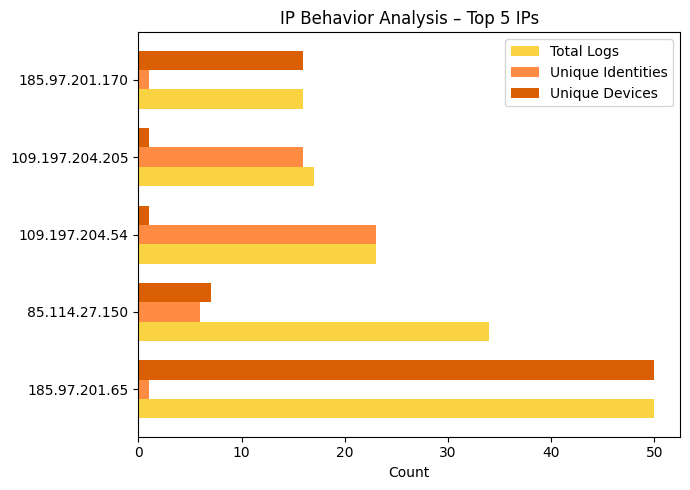

In [17]:

# Extract top 5 IPs with behavior fields
top5 = behavior_report.head(5).copy()

# Prepare metrics
ips = top5["ip"].values
counts = top5["total_appears"].values
unique_ids = top5["unique_identities"].values
unique_devices = top5["unique_devices"].values

# Number of groups
x = np.arange(len(ips))
width = 0.25

plt.figure(figsize=(7, 5))

plt.barh(x - width, counts, height=0.25, label='Total Logs', color="#F9D342")
plt.barh(x, unique_ids, height=0.25, label='Unique Identities', color="#FF8C42")
plt.barh(x + width, unique_devices, height=0.25, label='Unique Devices', color="#D95F02")


plt.yticks(x, ips)
plt.xlabel("Count")
plt.title("IP Behavior Analysis – Top 5 IPs")
plt.legend()
plt.tight_layout()
plt.show()


-----------------------------

##  **4: Cross-Column Integrity Checks**
o *ensure structural consistency and detect early anomalies, the following key relationships were evaluated:*

- Identity ↔ Device ID

- Identity ↔ IP Address

- Identity ↔ Device Fingerprint

- Device ID ↔ IP Address

- Device ID ↔ Fingerprint

- Bank ↔ Devices

- Bank ↔ Identity

*These mappings provide the foundation for identifying abnormal access patterns, device inconsistencies, and potential fraud-link behavior*.

### **4.1: identity → device** 

In [18]:
# ===1-  Create identity → device count table ===
id_dev = (
    df.groupby("identity")["device_id"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index()
      .head(10)
)
id_dev.columns = ["Identity", "Unique_Devices"]


# === Create device → identity count table ===
dev_id = (
    df.groupby("device_id")["identity"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index()
      .head(10)
)
dev_id.columns = ["Device_ID", "Unique_Identities"]


# === Merge both tables side-by-side ===
merged = pd.concat([id_dev, dev_id], axis=1)

from IPython.display import Markdown, display

# Build markdown table
md = "### 1- Identity vs Device / Device vs Identity Table (Top 10)\n\n"
md += "| **Identity** | **Unique Devices** | **Device_ID** | **Unique Identities** |\n"
md += "|--------------|---------------------|----------------|------------------------|\n"

for _, row in merged.iterrows():
    md += f"| {row['Identity']} | *{row['Unique_Devices']}* | {row['Device_ID']} | *{row['Unique_Identities']}* |\n"

display(Markdown(md))


### 1- Identity vs Device / Device vs Identity Table (Top 10)

| **Identity** | **Unique Devices** | **Device_ID** | **Unique Identities** |
|--------------|---------------------|----------------|------------------------|
| 37294473 | *102* | 614d661d-3a4d-47db-9e2b-874e481260ea | *195* |
| - | *36* | 0e1cf08b-671a-4444-b937-05b673c24b02 | *107* |
| 2577384 | *10* | d322c04b-4a97-40db-8538-f7ca54d5c41d | *42* |
| 67853893 | *10* | 2f756abe-6fff-46ae-8f1a-5f9da02f4274 | *7* |
| ce639ec37978863a9050c2669b57da3ef1aa970b | *8* | 34f77a86-f56e-4b24-b4a0-4cecd4baa5ff | *5* |
| 38e3a3139448cac457be3e8c87bb784d2b9f39eb | *8* | f8a16f59-2214-4bdd-98b3-018405758d33 | *4* |
| fa2a905ebe10d624a5be40bfe81766e0282dd374 | *6* | 397b2ad3-29dc-4b3c-8bbd-8bf24c76ea0d | *3* |
| fe593f13a0a4444f16197a3ca85563ce69c2ad4b | *5* | a3de5f78-0679-49a8-b298-2f7bcea6a906 | *3* |
| 0004dcae0b5342c42c060fa0bde43c087ff728b7 | *4* | 966adebc-0519-4f80-b748-b6985bc6f6c2 | *3* |
| 13944790 | *4* | 4f160116-8ba9-42c1-8403-a654576eeadc | *3* |


**Insight:**  
The bidirectional spikes in identity device links confirm a nonhuman pattern:
 a few identities use many devices, and a few devices generate many identities.
  This symmetry of abnormal volume is a definitive signature of automated fraud infrastructure.

### **4.2:  Identity → IP**

In [19]:
# === 2-  Identity → IP count ===
id_ip = (
    df.groupby("identity")["ips"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index()
      .head(10)
)
id_ip.columns = ["Identity", "Unique_IPs"]

# === 2) IP → Identity count ===
ip_id = (
    df.groupby("ips")["identity"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index()
      .head(10)
)
ip_id.columns = ["IP_Address", "Unique_Identities"]

# === Merge both ===
merged_ip = pd.concat([id_ip, ip_id], axis=1)

# === Markdown Table ===
md = "### 2- Identity vs IP Address/ IP Address vs Identity (Top 10)\n\n"
md += "| **Identity** | **Unique IPs** | **IP Address** | **Unique Identities** |\n"
md += "|--------------|----------------|----------------|------------------------|\n"

for _, row in merged_ip.iterrows():
    md += f"| {row['Identity']} | *{row['Unique_IPs']}* | {row['IP_Address']} | *{row['Unique_Identities']}* |\n"

display(Markdown(md))


### 2- Identity vs IP Address/ IP Address vs Identity (Top 10)

| **Identity** | **Unique IPs** | **IP Address** | **Unique Identities** |
|--------------|----------------|----------------|------------------------|
| 2577384 | *394* | 109.197.204.54 | *23* |
| - | *165* | 109.197.204.205 | *16* |
| 3f7491f892ab7a3cc46cf3d4e43e11c3553bc937 | *135* | 109.197.204.189 | *14* |
| 0007f265568f1abc1da791e852877df2047b3af9 | *70* | 109.197.204.190 | *12* |
| 0004dcae0b5342c42c060fa0bde43c087ff728b7 | *58* | 109.197.204.214 | *10* |
| e5e9a965a44bfccce49be788a6095cc563f4d503 | *34* | 109.197.204.15 | *9* |
| 15330202 | *29* | 176.59.40.185 | *9* |
| e7190874862efef8d3acd53baba84bc54f29d111 | *27* | 176.59.53.36 | *9* |
| 0002f6d69f6795f79e5959eb851a478c04c0a39f | *20* | 176.59.47.36 | *8* |
| fa2a905ebe10d624a5be40bfe81766e0282dd374 | *18* | 109.197.204.221 | *8* |


**Insight:**  
Identity vs IP asymmetry confirms fraud activity. Certain identities rotate across many IPs, while specific IPs are used by many  identities.
 This dual abnormality is a clear signature of proxy-based automation and coordinated identity cycling.

### **4.3 : Identity → Fingerprint**

In [20]:
# === 3- Identity → Fingerprint count ===
id_fp = (
    df.groupby("identity")["device_fingerprint"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index()
      .head(10)
)
id_fp.columns = ["Identity", "Unique_Fingerprints"]

# === 2) Fingerprint → Identity count ===
fp_id = (
    df.groupby("device_fingerprint")["identity"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index()
      .head(10)
)
fp_id.columns = ["Device_Fingerprint", "Unique_Identities"]

# === Merge both results ===
merged_fp = pd.concat([id_fp, fp_id], axis=1)

# === Build Markdown Table ===
md = "### 3- Identity vs Device Fingerprint / Device Fingerprint vs Identity  (Top 10)\n\n"
md += "| **Identity** | **Unique Fingerprints** | **Device Fingerprint** | **Unique Identities** |\n"
md += "|--------------|--------------------------|--------------------------|------------------------|\n"

for _, row in merged_fp.iterrows():
    md += f"| {row['Identity']} | *{row['Unique_Fingerprints']}* | {row['Device_Fingerprint']} | *{row['Unique_Identities']}* |\n"

display(Markdown(md))


### 3- Identity vs Device Fingerprint / Device Fingerprint vs Identity  (Top 10)

| **Identity** | **Unique Fingerprints** | **Device Fingerprint** | **Unique Identities** |
|--------------|--------------------------|--------------------------|------------------------|
| - | *26* | C45D75CA94FD92796B0F51000CF754B035AA4E48 | *195* |
| 38e3a3139448cac457be3e8c87bb784d2b9f39eb | *8* | 1928f95c59-a1ec271658-d77bb43915-66ae47db59 | *116* |
| ce639ec37978863a9050c2669b57da3ef1aa970b | *6* | b48af28979-116c56e539-9b9e431e93-87a831f69f | *14* |
| fa2a905ebe10d624a5be40bfe81766e0282dd374 | *6* | No data | *6* |
| 13944790 | *4* | cd38d47a3e-035b0b3e18-3e9e2f5cfc-56bb7522d8 | *5* |
| 15330202 | *3* | 79f3862c68-0e966a885e-14beccd0a0-009fdfa3aa | *4* |
| 0004dcae0b5342c42c060fa0bde43c087ff728b7 | *3* | 79f3862c68-9ec7fe9b41-4e81f224c7-d3277d9dd0 | *4* |
| 00064120f0aa15e8c4197cf9f18a03a6e4bd35cb | *3* | 53f112cc1e-f3e62aeba0-ef8a92c191-2cd4e7b04b | *3* |
| 67853893 | *3* | 6413e837d3-987e3415d7-d623bd6f2d-27c94f86d9 | *3* |
| fc95201d14d917c9abea75dc14136474b9930380 | *3* | 732dfee5-5945-43cf-af58-6494b6055e60 | *3* |


**Insight:**  
Identity–fingerprint asymmetry indicates automation. Some identities rotate across multiple fingerprints, while certain fingerprints generate many identities. This dual abnormality reflects cloned device environments and scripted identity cycling, a known signature of emulator based fraud operations.


### **4.4 :  Device → IP count**

In [21]:
# ===4- Device → IP count ===
dev_ip = (
    df.groupby("device_id")["ips"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index()
      .head(10)
)
dev_ip.columns = ["Device_ID", "Unique_IPs"]

# === 2) IP → Device count ===
ip_dev = (
    df.groupby("ips")["device_id"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index()
      .head(10)
)
ip_dev.columns = ["IP_Address", "Unique_Devices"]

# === Merge both sides ===
merged_dev_ip = pd.concat([dev_ip, ip_dev], axis=1)

# === Markdown table ===
md = "### 4-  Device ID ↔ IP Address Relationship (Top 10)\n\n"
md += "| **Device_ID** | **Unique IPs** | **IP Address** | **Unique Devices** |\n"
md += "|---------------|----------------|----------------|---------------------|\n"

for _, row in merged_dev_ip.iterrows():
    md += f"| {row['Device_ID']} | *{row['Unique_IPs']}* | {row['IP_Address']} | *{row['Unique_Devices']}* |\n"

display(Markdown(md))


### 4-  Device ID ↔ IP Address Relationship (Top 10)

| **Device_ID** | **Unique IPs** | **IP Address** | **Unique Devices** |
|---------------|----------------|----------------|---------------------|
| 614d661d-3a4d-47db-9e2b-874e481260ea | *177* | 185.97.201.65 | *50* |
| 5117890b-913b-40a8-b6cb-869f85a306c1 | *131* | 185.97.201.170 | *16* |
| a3de5f78-0679-49a8-b298-2f7bcea6a906 | *88* | 217.66.152.216 | *15* |
| 1535ac5c-8f64-4dd6-a150-80b576b1df54 | *87* | 185.97.201.89 | *12* |
| a57e8208-9b8e-4baa-b1f3-2a8050834a82 | *82* | 85.114.27.150 | *7* |
| 0e1cf08b-671a-4444-b937-05b673c24b02 | *69* | 217.66.159.132 | *6* |
| 5ed74c2d-ee31-4d61-b01f-cd6d9b1fbc50 | *58* | 5.18.235.235 | *5* |
| 5d2c2da3-0d53-4444-a625-2480606e2c29 | *44* | 5.18.248.133 | *4* |
| cdaa8673-164d-44a7-80a0-99cd4cfe3818 | *44* | 197.210.227.134 | *3* |
| dfb33dfd-fef5-4fd7-8382-4fab34d50966 | *26* | 197.210.71.248 | *3* |


**Insight:**  
Device vs IP asymmetry shows clear fraud signaling. Some devices rotate across many IPs (proxy automation), while certain IPs serve multiple devices (shared fraud nodes). This pattern strongly indicates coordinated network level evasion.

### **4.5: Device → Fingerprint**

In [22]:
# === 5-  Device → Fingerprint count ===
dev_fp = (
    df.groupby("device_id")["device_fingerprint"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index()
      .head(10)
)
dev_fp.columns = ["Device_ID", "Unique_Fingerprints"]

# === 2) Fingerprint → Device count ===
fp_dev = (
    df.groupby("device_fingerprint")["device_id"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index()
      .head(10)
)
fp_dev.columns = ["Device_Fingerprint", "Unique_Devices"]

# === Merge both results side-by-side ===
merged_dev_fp = pd.concat([dev_fp, fp_dev], axis=1)

# === Build Markdown table ===
md = "### 5- Device ID ↔ Device Fingerprint Relationship (Top 10)\n\n"
md += "| **Device_ID** | **Unique Fingerprints** | **Device Fingerprint** | **Unique Devices** |\n"
md += "|---------------|--------------------------|-------------------------|---------------------|\n"

for _, row in merged_dev_fp.iterrows():
    md += f"| {row['Device_ID']} | *{row['Unique_Fingerprints']}* | {row['Device_Fingerprint']} | *{row['Unique_Devices']}* |\n"

display(Markdown(md))


### 5- Device ID ↔ Device Fingerprint Relationship (Top 10)

| **Device_ID** | **Unique Fingerprints** | **Device Fingerprint** | **Unique Devices** |
|---------------|--------------------------|-------------------------|---------------------|
| 00993a56-f44b-448d-9d33-78c16f0be636 | *1* | b48af28979-116c56e539-9b9e431e93-87a831f69f | *113* |
| 02591b70-e8f5-4299-901c-e78b2b79b526 | *1* | No data | *6* |
| 0346a33f-a178-43ce-abf1-7b9d529f13a4 | *1* | 6413e837d3-987e3415d7-d623bd6f2d-27c94f86d9 | *5* |
| 0379b9a6-c38f-4380-8998-8ee9e63e9e22 | *1* | 6413e837d3-987e3415d7-902dcc5844-27c94f86d9 | *5* |
| 07e5a1d3-572d-4d5c-b7df-f903c9533fa7 | *1* | 6413e837d3-987e3415d7-0477bed160-27c94f86d9 | *5* |
| 0a6a1d8c-0be2-4861-922d-ac15d4ac23c2 | *1* | 79f3862c68-0e966a885e-14beccd0a0-009fdfa3aa | *3* |
| 0b41fbf2-5a5d-43ac-8a67-91def411f9c6 | *1* | 6413e837d3-04f207596d-d96f6a660e-f9467a0b11 | *2* |
| 0d78fa6d-200e-4c39-9cbc-e834b11e460e | *1* | 1928f95c59-a1ec271658-d77bb43915-66ae47db59 | *2* |
| 0e1cf08b-671a-4444-b937-05b673c24b02 | *1* | 1928f95c59-4e8562b52e-3b9a7a7672-e1c6e753b0 | *1* |
| 0f432be7-7bf0-4d06-ad3a-1111cf6c8efb | *1* | 1928f95c59-387c56e5f6-eee6e2e4c8-987fa76817 | *1* |


**Insight:**  
The results show that while individual devices report a single consistent fingerprint, one fingerprint appears across 113 different devices. This pattern is not consistent with real hardware and strongly suggests the use of virtual or cloned devices within an emulator environment.

#### **4.6: Bank → Unique Devices**

In [23]:
# === 6- Bank → Unique Devices count ===
bank_dev = (
    df.groupby("bank")["device_id"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index()
      .head(10)
)
bank_dev.columns = ["Bank", "Unique_Devices"]

# === 2) Device → Unique Banks count ===
dev_bank = (
    df.groupby("device_id")["bank"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index()
      .head(10)
)
dev_bank.columns = ["Device_ID", "Unique_Banks"]

# === Merge both views side-by-side ===
merged_bank_dev = pd.concat([bank_dev, dev_bank], axis=1)

# === Markdown Table ===
md = "### 6-  Bank ↔ Device Relationship (Top 10)\n\n"
md += "| **Bank** | **Unique Devices** | **Device ID** | **Unique Banks** |\n"
md += "|----------|----------------------|----------------|-------------------|\n"

for _, row in merged_bank_dev.iterrows():
    md += f"| {row['Bank']} | *{row['Unique_Devices']}* | {row['Device_ID']} | *{row['Unique_Banks']}* |\n"

display(Markdown(md))


### 6-  Bank ↔ Device Relationship (Top 10)

| **Bank** | **Unique Devices** | **Device ID** | **Unique Banks** |
|----------|----------------------|----------------|-------------------|
| Bank1 | *117* | 00993a56-f44b-448d-9d33-78c16f0be636 | *1* |
| Bank10 | *15* | 02591b70-e8f5-4299-901c-e78b2b79b526 | *1* |
| Bank2 | *10* | 0346a33f-a178-43ce-abf1-7b9d529f13a4 | *1* |
| Bank11 | *5* | 0379b9a6-c38f-4380-8998-8ee9e63e9e22 | *1* |
| Bank4 | *5* | 07e5a1d3-572d-4d5c-b7df-f903c9533fa7 | *1* |
| Bank8 | *5* | 0a6a1d8c-0be2-4861-922d-ac15d4ac23c2 | *1* |
| Bank6 | *4* | 0b41fbf2-5a5d-43ac-8a67-91def411f9c6 | *1* |
| Bank9 | *3* | 0d78fa6d-200e-4c39-9cbc-e834b11e460e | *1* |
| Bank5 | *3* | 0e1cf08b-671a-4444-b937-05b673c24b02 | *1* |
| Bank3 | *1* | 0f432be7-7bf0-4d06-ad3a-1111cf6c8efb | *1* |


**Insights**
- The relationship between banks and devices typically shows high volume and high diversity, since each bank naturally serves many legitimate users across different devices.

- In this dataset, all devices appear to be linked to only one bank each, which is structurally normal and expected in real environments unless cross-bank attacks are taking place.

- No device shows access across multiple banks, meaning no cross-bank fraud behavior is indicated in this segment.

- While this feature is necessary to check for multi-bank device reuse (a strong fraud signal), the current results do not reveal abnormal behavior.


In [24]:
# === 6- asn → Unique identity count ===
identity_asn = (
    df.groupby("identity")["asn"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index()
      .head(10)
)
identity_asn.columns = ["identity", "Unique_asn"]

# === 2) asn → Unique identity ===
asn_identity = (
    df.groupby("asn")["identity"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index()
      .head(10)
)
asn_identity.columns = ["asn", "Unique_identity"]

# === Merge both views side-by-side ===
merged_identity_asn = pd.concat([identity_asn, asn_identity], axis=1)

# === Markdown Table ===
md = "### 6-  identity ↔ Asn Relationship (Top 10)\n\n"
md += "| **identity** | **Unique_asn** | **asn** | **Unique_identity** |\n"
md += "|----------|----------------------|----------------|-------------------|\n"

for _, row in merged_identity_asn.iterrows():
    md += f"| {row['identity']} | *{row['Unique_asn']}* | {row['asn']} | *{row['Unique_identity']}* |\n"

display(Markdown(md))


### 6-  identity ↔ Asn Relationship (Top 10)

| **identity** | **Unique_asn** | **asn** | **Unique_identity** |
|----------|----------------------|----------------|-------------------|
| - | *28* | 12958.0 | *192* |
| 2577384 | *17* | 16345.0 | *112* |
| 0004dcae0b5342c42c060fa0bde43c087ff728b7 | *10* | 8359.0 | *47* |
| fa2a905ebe10d624a5be40bfe81766e0282dd374 | *9* | 12389.0 | *10* |
| 38e3a3139448cac457be3e8c87bb784d2b9f39eb | *8* | 41733.0 | *8* |
| 37294473 | *6* | 35125.0 | *7* |
| e5e9a965a44bfccce49be788a6095cc563f4d503 | *5* | 8492.0 | *6* |
| 0007f265568f1abc1da791e852877df2047b3af9 | *4* | 5384.0 | *5* |
| 67853893 | *4* | 25513.0 | *4* |
| 13944790 | *4* | 31213.0 | *4* |


**Insights**

- Several identities show unusually high ASN diversity, indicating repeated network switching across multiple internet providers.
-  This pattern is inconsistent with legitimate user behavior and strongly aligns with VPN/proxy-based automation. Conversely, multiple identities cluster under the same ASN, suggesting centralized routing points typically used in coordinated fraud infrastructure. 
- These bi directional anomalies reinforce the hypothesis of nonhuman, scripted, and infrastructure-driven activity.

-------------------------

## **5- Cross-Feature Correlation Analysis**
- This analysis evaluates the correlation between critical features (IP, device, identity, bank, country) to detect whether these elements move consistently as expected in legitimate user behavior or display weak, unstable patterns typically associated with fraudulent activity.
------------------------

In [25]:
#Define the correlation function
def compute_correlation(df, col1, col2):
    """
    Computes correlation between two categorical columns
    by converting each category to integer codes.
    """
    try:
        temp = df[[col1, col2]].dropna().copy()
        temp[col1] = temp[col1].astype('category').cat.codes
        temp[col2] = temp[col2].astype('category').cat.codes
        corr = temp[col1].corr(temp[col2])
        return round(corr, 3)
    except:
        return None


# ----------- Define all correlation pairs -----------
correlation_pairs = [
    ("ips", "bank"),
    ("ips", "device_fingerprint"),
    ("device_fingerprint", "identity"),
    ("device_fingerprint", "bank"),
    ("bank", "identity"),
    ("device_id", "bank"),
    ("device_id", "os_name"),
    ("device_id", "country"),
    ("ips","device_id"),
    ("ips","identity"),
    ("identity","device_id")
]


results = []

for col1, col2 in correlation_pairs:
    corr_value = compute_correlation(df, col1, col2)

    # Interpretation
    if corr_value is None:
        interpretation = "Not enough data"
    elif abs(corr_value) < 0.20:
        interpretation = "Very weak link – likely random or fraudulent behavior"
    elif abs(corr_value) < 0.40:
        interpretation = "Weak link – inconsistent patterns"
    elif abs(corr_value) < 0.70:
        interpretation = "Moderate link – partially consistent"
    else:
        interpretation = "Strong link – consistent and stable behavior"

    results.append({
        "Feature Pair": f"{col1} ↔ {col2}",
        "Correlation": corr_value,
        "Interpretation": interpretation
    })


correlation_table = pd.DataFrame(results)

print("=== Cross-Feature Correlation Summary ===")
display(correlation_table)


=== Cross-Feature Correlation Summary ===


,Feature Pair,Correlation,Interpretation
0,ips ↔ bank,-0.501,Moderate link – partially consistent
1,ips ↔ device_fingerprint,0.111,Very weak link – likely random or fraudulent b...
2,device_fingerprint ↔ identity,-0.009,Very weak link – likely random or fraudulent b...
3,device_fingerprint ↔ bank,-0.242,Weak link – inconsistent patterns
4,bank ↔ identity,0.141,Very weak link – likely random or fraudulent b...
5,device_id ↔ bank,-0.352,Weak link – inconsistent patterns
6,device_id ↔ os_name,0.211,Weak link – inconsistent patterns
7,device_id ↔ country,-0.021,Very weak link – likely random or fraudulent b...
8,ips ↔ device_id,0.162,Very weak link – likely random or fraudulent b...
9,ips ↔ identity,0.016,Very weak link – likely random or fraudulent b...


**Insights**
-------
**ips ↔ bank (-0.501)**
- Moderate negative link  
- IPs do not consistently match banks  
- Suggests VPN use or location switching  

**ips ↔ device_fingerprint (0.111)**
- Very weak link  
- Devices are not tied to stable IPs  
- Indicates IP rotation or automated behavior  

**device_fingerprint ↔ identity (-0.009)**
- Near-zero link  
- Devices do not match identities  
- Possible fraud ring or fake fingerprints  

**device_fingerprint ↔ bank (-0.242)**
- Weak negative link  
- Same device fingerprint used across different banks  
- Inconsistent and suspicious activity  

**bank ↔ identity (0.141)**
- Very weak link  
- Identities are not tied to specific banks  
- May indicate non-genuine or inconsistent users  

**device_id ↔ bank (-0.352)**
- Weak negative link  
- Same device appears across multiple banks  
- Suggests spoofing or emulator usage  

**device_id ↔ country (0.211)**
- Weak link  
- Device location is not stable  
- Indicates VPN or geo-masking  

**ips ↔ device_id (0.082)**
- Very weak link  
- Devices do not keep a consistent IP  
- Often seen in automated fraud networks  

**ips ↔ identity (0.016)**
- Near-zero link  
- Identities not tied to stable IPs  
- Highly abnormal for real users  

**identity ↔ device_id (-0.106)**
- Very weak negative link  
- Identities do not consistently use the same device  
- Suggests multiple identities controlled by spoofed devices  

**Overall Conclusion**
- Weak/negative correlations dominate  
- No human-like consistency across features  
- Strong indication of fraud infrastructure (VPN, emulators, spoofing)


--------------------